### Reading data from a xls file or csv file
### Reading data from a Database: sql, nosql (MongoDB) (CRUD)

* Read the data from xls file: Telemetry
* Store the same data that is read from xls to sql and MongoDB
* Read back the data from the MongoDB and sql
* For a given time stamp, change any one of the values of the data. 
* Read one more xls file, which is the events file: Events
* Combine both the files and organize it as per time stamp 


In [1]:
import pandas as pd
telemetry_df = pd.read_csv('telemetry.csv')
telemetry_df.head()

,date,timestamp,site_id,serial_num,duration,ac_voltage,ac_frequency,dc_voltage,dc_current,temperature,error_seconds,energy
0,2023-08-01,2023-08-01T17:42:18Z,4490206,202307218285,33,247.12,59.98,34.95,0.01,36,0,0
1,2023-08-01,2023-08-01T17:47:40Z,4490206,202307218285,322,247.25,59.90,34.56,0.01,35,0,0
2,2023-08-01,2023-08-01T17:48:04Z,4490206,202307218285,24,246.59,59.99,34.60,0.01,35,0,0
3,2023-08-01,2023-08-01T18:03:20Z,4490206,202307218285,916,245.69,60.07,30.10,0.07,34,0,0
4,2023-08-01,2023-08-01T18:18:35Z,4490206,202307218285,915,247.50,60.07,35.07,0.02,33,0,0


In [2]:
# for column in telemetry_df.columns:
#     print(f"{column} varchar(255),")
    
# for column in telemetry_df.columns:
#     print(f"'{column}': 'varchar(255)'", end=', ')
    
for column in telemetry_df.columns:
    print("{telemetry_df.loc[row]['"+column+"']},", end="") 



{telemetry_df.loc[row]['date']},{telemetry_df.loc[row]['timestamp']},{telemetry_df.loc[row]['site_id']},{telemetry_df.loc[row]['serial_num']},{telemetry_df.loc[row]['duration']},{telemetry_df.loc[row]['ac_voltage']},{telemetry_df.loc[row]['ac_frequency']},{telemetry_df.loc[row]['dc_voltage']},{telemetry_df.loc[row]['dc_current']},{telemetry_df.loc[row]['temperature']},{telemetry_df.loc[row]['error_seconds']},{telemetry_df.loc[row]['energy']},

In [3]:
import pyodbc

connection = pyodbc.connect('DRIVER={ODBC Driver 17 for SQL Server};'
                            'SERVER=TPSYS-2132;'
                            'DATABASE=TrainingDB;'
                            'UID=sa;'
                            'PWD=Admin@123;')

cursor = connection.cursor()



connection.commit()

In [4]:
cursor.execute('DROP TABLE IF EXISTS telemetry')
cursor.execute('''
CREATE TABLE telemetry (
[date] date,
[timestamp] datetime,
[site_id] bigint,
[serial_num] bigint,
[duration] int,
[ac_voltage] decimal(10, 2),
[ac_frequency] decimal(10, 2),
[dc_voltage] decimal(10, 2),
[dc_current] decimal(10, 2),
[temperature] int,
[error_seconds] int,
[energy] int
)''')

In [5]:
for row in range(telemetry_df.shape[0]):
    query = "INSERT INTO telemetry VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)"
    values = (
        telemetry_df.loc[row]['date'],
        telemetry_df.loc[row]['timestamp'],
        int(telemetry_df.loc[row]['site_id']),
        int(telemetry_df.loc[row]['serial_num']),
        int(telemetry_df.loc[row]['duration']),
        float(telemetry_df.loc[row]['ac_voltage']),
        float(telemetry_df.loc[row]['ac_frequency']),
        float(telemetry_df.loc[row]['dc_voltage']),
        float(telemetry_df.loc[row]['dc_current']),
        int(telemetry_df.loc[row]['temperature']),
        int(telemetry_df.loc[row]['error_seconds']),
        int(telemetry_df.loc[row]['energy'])
    )
    cursor.execute(query, values)

In [6]:
cursor.execute('SELECT * FROM telemetry')


all_data = list()


for row in cursor:
    data = dict()
    for i in range(len(row)):
        data[telemetry_df.columns[i]] = row[i]
    all_data.append(data)
        
data_from_sql = pd.DataFrame(all_data)     
data_from_sql




,date,timestamp,site_id,serial_num,duration,ac_voltage,ac_frequency,dc_voltage,dc_current,temperature,error_seconds,energy
0,2023-08-01,2023-08-01 17:42:18,4490206,202307218285,33,247.12,59.98,34.95,0.01,36,0,0
1,2023-08-01,2023-08-01 17:47:40,4490206,202307218285,322,247.25,59.90,34.56,0.01,35,0,0
2,2023-08-01,2023-08-01 17:48:04,4490206,202307218285,24,246.59,59.99,34.60,0.01,35,0,0
3,2023-08-01,2023-08-01 18:03:20,4490206,202307218285,916,245.69,60.07,30.10,0.07,34,0,0
4,2023-08-01,2023-08-01 18:18:35,4490206,202307218285,915,247.50,60.07,35.07,0.02,33,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
18659,2023-08-27,2023-08-27 17:34:27,4490206,202307229413,933,249.19,59.92,35.55,0.74,40,0,8
18660,2023-08-27,2023-08-27 17:49:59,4490206,202307229413,932,249.66,60.09,35.09,0.73,38,0,7
18661,2023-08-27,2023-08-27 18:06:21,4490206,202307229413,982,249.84,59.96,33.19,0.57,38,0,6
18662,2023-08-27,2023-08-27 18:21:38,4490206,202307229413,917,251.34,60.00,30.70,0.22,36,0,3


In [7]:
cursor.close()
connection.close()

In [8]:
# connection using mongoDB

In [ ]:
from pymongo.mongo_client import MongoClient
from pymongo.server_api import ServerApi

uri = ""

client = MongoClient(uri, server_api=ServerApi('1'))

try:
    client.admin.command('ping')
    print("Successfully connected to MongoDB!")
except Exception as e:
    print(e)

Successfully connected to MongoDB!


In [10]:
db = client['TrainingDB']  
collection = db['Telemetry']  

In [11]:
data_to_insert = telemetry_df.to_dict(orient='records')

In [12]:
try:
    collection.insert_many(data_to_insert)
    print("Data inserted successfully into MongoDB!")
except Exception as e:
    print(f"Error inserting data: {e}")


Data inserted successfully into MongoDB!


In [13]:
cursor = collection.find()

In [14]:
data_from_mongodb = pd.DataFrame(list(cursor))

In [15]:
data_from_mongodb.head()

,_id,date,timestamp,site_id,serial_num,duration,ac_voltage,ac_frequency,dc_voltage,dc_current,temperature,error_seconds,energy
0,65c0d22ac724c1c4b21ceab9,2023-08-01,2023-08-01T17:42:18Z,4490206,202307218285,33,247.12,59.98,34.95,0.01,36,0,0
1,65c0d22ac724c1c4b21ceaba,2023-08-01,2023-08-01T17:47:40Z,4490206,202307218285,322,247.25,59.90,34.56,0.01,35,0,0
2,65c0d22ac724c1c4b21ceabb,2023-08-01,2023-08-01T17:48:04Z,4490206,202307218285,24,246.59,59.99,34.60,0.01,35,0,0
3,65c0d22ac724c1c4b21ceabc,2023-08-01,2023-08-01T18:03:20Z,4490206,202307218285,916,245.69,60.07,30.10,0.07,34,0,0
4,65c0d22ac724c1c4b21ceabd,2023-08-01,2023-08-01T18:18:35Z,4490206,202307218285,915,247.50,60.07,35.07,0.02,33,0,0


In [16]:
collection.update_one({"timestamp": "2023-08-01T17:47:58Z"}, {"$set": {"site_id": "30"}})

UpdateResult({'n': 1, 'electionId': ObjectId('7fffffff0000000000000014'), 'opTime': {'ts': Timestamp(1707310743, 4), 't': 20}, 'nModified': 1, 'ok': 1.0, '$clusterTime': {'clusterTime': Timestamp(1707310743, 4), 'signature': {'hash': b'D\xcc\xe4\xe4\xc6\xbaS\xe5\xa3|@\xbbO\xc2\xca\xe1\n\xb1v\xcf', 'keyId': 7306486278193676293}}, 'operationTime': Timestamp(1707310743, 4), 'updatedExisting': True}, acknowledged=True)

In [17]:
cursor = collection.find({"timestamp": "2023-08-01T17:47:58Z"})
data = pd.DataFrame(list(cursor))
data

,_id,date,timestamp,site_id,serial_num,duration,ac_voltage,ac_frequency,dc_voltage,dc_current,temperature,error_seconds,energy
0,65c224a61e7b36ba8d58eafd,2023-08-01,2023-08-01T17:47:58Z,30,202307226911,23,246.84,59.95,34.46,0.02,34,0,0
1,65c312d3dab111b14bfc0aaa,2023-08-01,2023-08-01T17:47:58Z,4490206,202307226911,23,246.84,59.95,34.46,0.02,34,0,0
2,65c349f096607926f4e17ae3,2023-08-01,2023-08-01T17:47:58Z,4490206,202307226911,23,246.84,59.95,34.46,0.02,34,0,0
3,65c35c128375c597cfbbf792,2023-08-01,2023-08-01T17:47:58Z,4490206,202307226911,23,246.84,59.95,34.46,0.02,34,0,0
4,65c3637e46be81d265715b2a,2023-08-01,2023-08-01T17:47:58Z,4490206,202307226911,23,246.84,59.95,34.46,0.02,34,0,0
5,65c37e649c72a6ddc165ea54,2023-08-01,2023-08-01T17:47:58Z,4490206,202307226911,23,246.84,59.95,34.46,0.02,34,0,0


In [18]:
collection.delete_one({"site_id":"30"})

DeleteResult({'n': 1, 'electionId': ObjectId('7fffffff0000000000000014'), 'opTime': {'ts': Timestamp(1707310743, 11), 't': 20}, 'ok': 1.0, '$clusterTime': {'clusterTime': Timestamp(1707310743, 11), 'signature': {'hash': b'D\xcc\xe4\xe4\xc6\xbaS\xe5\xa3|@\xbbO\xc2\xca\xe1\n\xb1v\xcf', 'keyId': 7306486278193676293}}, 'operationTime': Timestamp(1707310743, 11)}, acknowledged=True)

In [19]:
cursor = collection.find({"timestamp": "2023-08-01T17:47:58Z"}, {"_id": 0})
data = pd.DataFrame(list(cursor))
data

,date,timestamp,site_id,serial_num,duration,ac_voltage,ac_frequency,dc_voltage,dc_current,temperature,error_seconds,energy
0,2023-08-01,2023-08-01T17:47:58Z,4490206,202307226911,23,246.84,59.95,34.46,0.02,34,0,0
1,2023-08-01,2023-08-01T17:47:58Z,4490206,202307226911,23,246.84,59.95,34.46,0.02,34,0,0
2,2023-08-01,2023-08-01T17:47:58Z,4490206,202307226911,23,246.84,59.95,34.46,0.02,34,0,0
3,2023-08-01,2023-08-01T17:47:58Z,4490206,202307226911,23,246.84,59.95,34.46,0.02,34,0,0
4,2023-08-01,2023-08-01T17:47:58Z,4490206,202307226911,23,246.84,59.95,34.46,0.02,34,0,0


In [20]:
client.close()

In [21]:
event_df = pd.read_csv('events.csv')

In [22]:
event_df.head()

,site_id,serial_num,event_type_id,event_key,stateful,event_start_timestamp,event_clear_timestamp
0,4490206,202307228109,14,commanded_reset,0,2023-08-01T17:47:36Z,2023-08-01T17:47:36Z
1,4490206,202307227203,14,commanded_reset,0,2023-08-01T17:47:34Z,2023-08-01T17:47:34Z
2,4490206,202307227367,14,commanded_reset,0,2023-08-01T17:47:34Z,2023-08-01T17:47:34Z
3,4490206,202307227204,14,commanded_reset,0,2023-08-01T17:47:29Z,2023-08-01T17:47:29Z
4,4490206,202307227217,14,commanded_reset,0,2023-08-01T17:47:33Z,2023-08-01T17:47:33Z


In [23]:
telemetry_df.head()

,date,timestamp,site_id,serial_num,duration,ac_voltage,ac_frequency,dc_voltage,dc_current,temperature,error_seconds,energy
0,2023-08-01,2023-08-01T17:42:18Z,4490206,202307218285,33,247.12,59.98,34.95,0.01,36,0,0
1,2023-08-01,2023-08-01T17:47:40Z,4490206,202307218285,322,247.25,59.90,34.56,0.01,35,0,0
2,2023-08-01,2023-08-01T17:48:04Z,4490206,202307218285,24,246.59,59.99,34.60,0.01,35,0,0
3,2023-08-01,2023-08-01T18:03:20Z,4490206,202307218285,916,245.69,60.07,30.10,0.07,34,0,0
4,2023-08-01,2023-08-01T18:18:35Z,4490206,202307218285,915,247.50,60.07,35.07,0.02,33,0,0


In [24]:
merged_df = pd.merge(telemetry_df, event_df, left_on='timestamp', right_on='event_start_timestamp', how='inner')

In [25]:
merged_df.head()

,date,timestamp,site_id_x,serial_num_x,duration,ac_voltage,ac_frequency,dc_voltage,dc_current,temperature,error_seconds,energy,site_id_y,serial_num_y,event_type_id,event_key,stateful,event_start_timestamp,event_clear_timestamp
0,2023-08-01,2023-08-01T17:47:40Z,4490206,202307218285,322,247.25,59.90,34.56,0.01,35,0,0,4490206,202307218285,14,commanded_reset,0,2023-08-01T17:47:40Z,2023-08-01T17:47:40Z
1,2023-08-01,2023-08-01T18:18:35Z,4490206,202307218285,915,247.50,60.07,35.07,0.02,33,0,0,4490206,202307218285,2,ac_voltage_out_of_range,1,2023-08-01T18:18:35Z,2023-08-01T18:18:49Z
2,2023-08-01,2023-08-01T18:18:35Z,4490206,202307218285,915,247.50,60.07,35.07,0.02,33,0,0,4490206,202307218285,678,island_detected,1,2023-08-01T18:18:35Z,2023-08-01T18:18:49Z
3,2023-08-01,2023-08-01T18:18:35Z,4490206,202307218285,915,247.50,60.07,35.07,0.02,33,0,0,4490206,202307218285,1027,pcu_chan_loss_of_phase_12,1,2023-08-01T18:18:35Z,2023-08-01T18:18:49Z
4,2023-08-01,2023-08-01T18:18:49Z,4490206,202307218285,14,247.19,60.03,31.04,0.06,33,0,0,4490206,202307218285,3,ac_freq_out_of_range,1,2023-08-01T18:18:49Z,2023-08-01T18:18:49Z


In [26]:
# calculating the mean, median & mode in every 30 minutes

In [27]:
telemetry_df = pd.read_csv('telemetry.csv')

telemetry_df['timestamp']=pd.to_datetime(telemetry_df['timestamp'])
telemetry_df['date']=pd.to_datetime(telemetry_df['date'])

start_time = telemetry_df['timestamp'].min()
last_time = telemetry_df['timestamp'].max()
interval_time = start_time + pd.Timedelta(minutes=30)
sorted_df = telemetry_df.sort_values(by='timestamp')



while start_time < last_time:
    filtered_df = sorted_df[(sorted_df['timestamp'] >= start_time) & (sorted_df['timestamp'] <= interval_time)]
    print(f"Interval from {start_time} to {interval_time}")
    print("_______________________________________________________________\n")
    for col in filtered_df.columns:
        if filtered_df[col].dtype != 'object':
            mean = filtered_df[col].mean() if not filtered_df[col].empty else None
            median = filtered_df[col].median() if not filtered_df[col].empty else None
            mode = filtered_df[col].mode().iloc[0] if not filtered_df[col].empty else None
            
            result = {"mean": mean, "median":median, "mode":mode}
            print(f"{col} : {result}")
    print()
    start_time = interval_time
    interval_time = start_time + pd.Timedelta(minutes=30)


Interval from 2023-08-01 17:41:42+00:00 to 2023-08-01 18:11:42+00:00
_______________________________________________________________

date : {'mean': Timestamp('2023-08-01 00:00:00'), 'median': Timestamp('2023-08-01 00:00:00'), 'mode': Timestamp('2023-08-01 00:00:00')}
timestamp : {'mean': Timestamp('2023-08-01 17:49:25.151515136+0000', tz='UTC'), 'median': Timestamp('2023-08-01 17:47:41+0000', tz='UTC'), 'mode': Timestamp('2023-08-01 17:47:28+0000', tz='UTC')}
site_id : {'mean': 4490206.0, 'median': 4490206.0, 'mode': 4490206}
serial_num : {'mean': 202307227700.77777, 'median': 202307227563.0, 'mode': 202307226911}
duration : {'mean': 291.90909090909093, 'median': 120.0, 'mode': 322}
ac_voltage : {'mean': 246.71171717171717, 'median': 246.97, 'mode': 247.09}
ac_frequency : {'mean': 59.976363636363644, 'median': 59.97, 'mode': 59.98}
dc_voltage : {'mean': 33.573838383838385, 'median': 34.56, 'mode': 34.6}
dc_current : {'mean': 0.028181818181818183, 'median': 0.02, 'mode': 0.02}
tempera

Interval from 2023-08-03 05:41:42+00:00 to 2023-08-03 06:11:42+00:00
_______________________________________________________________

date : {'mean': Timestamp('2023-08-03 00:00:00'), 'median': Timestamp('2023-08-03 00:00:00'), 'mode': Timestamp('2023-08-03 00:00:00')}
timestamp : {'mean': Timestamp('2023-08-03 05:58:16.142857472+0000', tz='UTC'), 'median': Timestamp('2023-08-03 05:58:14.500000+0000', tz='UTC'), 'mode': Timestamp('2023-08-03 05:57:50+0000', tz='UTC')}
site_id : {'mean': 4490206.0, 'median': 4490206.0, 'mode': 4490206}
serial_num : {'mean': 202307227800.42856, 'median': 202307227347.5, 'mode': 202307226911}
duration : {'mean': 34.857142857142854, 'median': 34.0, 'mode': 34}
ac_voltage : {'mean': 251.70785714285714, 'median': 251.72, 'mode': 251.72}
ac_frequency : {'mean': 60.05642857142858, 'median': 60.07, 'mode': 60.07}
dc_voltage : {'mean': 33.64357142857143, 'median': 33.63, 'mode': 33.59}
dc_current : {'mean': 0.019285714285714288, 'median': 0.02, 'mode': 0.02}
tem

Interval from 2023-08-04 09:41:42+00:00 to 2023-08-04 10:11:42+00:00
_______________________________________________________________

date : {'mean': Timestamp('2023-08-04 00:00:00'), 'median': Timestamp('2023-08-04 00:00:00'), 'mode': Timestamp('2023-08-04 00:00:00')}
timestamp : {'mean': Timestamp('2023-08-04 09:58:05.964285696+0000', tz='UTC'), 'median': Timestamp('2023-08-04 09:58:15+0000', tz='UTC'), 'mode': Timestamp('2023-08-04 09:49:58+0000', tz='UTC')}
site_id : {'mean': 4490206.0, 'median': 4490206.0, 'mode': 4490206}
serial_num : {'mean': 202307227800.42856, 'median': 202307227347.5, 'mode': 202307226911}
duration : {'mean': 932.1071428571429, 'median': 932.0, 'mode': 932}
ac_voltage : {'mean': 250.2642857142857, 'median': 250.82999999999998, 'mode': 250.97}
ac_frequency : {'mean': 60.07249999999999, 'median': 60.05, 'mode': 60.19}
dc_voltage : {'mean': 34.70535714285714, 'median': 34.6, 'mode': 34.64}
dc_current : {'mean': 8.031071428571428, 'median': 9.18, 'mode': 9.15}
te

Interval from 2023-08-05 14:11:42+00:00 to 2023-08-05 14:41:42+00:00
_______________________________________________________________

date : {'mean': Timestamp('2023-08-05 00:00:00'), 'median': Timestamp('2023-08-05 00:00:00'), 'mode': Timestamp('2023-08-05 00:00:00')}
timestamp : {'mean': Timestamp('2023-08-05 14:23:04.642857216+0000', tz='UTC'), 'median': Timestamp('2023-08-05 14:22:59+0000', tz='UTC'), 'mode': Timestamp('2023-08-05 14:30:41+0000', tz='UTC')}
site_id : {'mean': 4490206.0, 'median': 4490206.0, 'mode': 4490206}
serial_num : {'mean': 202307227800.42856, 'median': 202307227347.5, 'mode': 202307226911}
duration : {'mean': 931.7142857142857, 'median': 932.0, 'mode': 932}
ac_voltage : {'mean': 250.8135714285714, 'median': 250.735, 'mode': 250.53}
ac_frequency : {'mean': 60.036071428571425, 'median': 60.04, 'mode': 60.05}
dc_voltage : {'mean': 34.183928571428574, 'median': 34.21, 'mode': 34.23}
dc_current : {'mean': 9.6775, 'median': 9.670000000000002, 'mode': 9.32}
temperat

Interval from 2023-08-06 21:11:42+00:00 to 2023-08-06 21:41:42+00:00
_______________________________________________________________

date : {'mean': None, 'median': None, 'mode': None}
timestamp : {'mean': None, 'median': None, 'mode': None}
site_id : {'mean': None, 'median': None, 'mode': None}
serial_num : {'mean': None, 'median': None, 'mode': None}
duration : {'mean': None, 'median': None, 'mode': None}
ac_voltage : {'mean': None, 'median': None, 'mode': None}
ac_frequency : {'mean': None, 'median': None, 'mode': None}
dc_voltage : {'mean': None, 'median': None, 'mode': None}
dc_current : {'mean': None, 'median': None, 'mode': None}
temperature : {'mean': None, 'median': None, 'mode': None}
error_seconds : {'mean': None, 'median': None, 'mode': None}
energy : {'mean': None, 'median': None, 'mode': None}

Interval from 2023-08-06 21:41:42+00:00 to 2023-08-06 22:11:42+00:00
_______________________________________________________________

date : {'mean': None, 'median': None, 'mode':

...

temperature : {'mean': 50.17857142857143, 'median': 50.0, 'mode': 50}
error_seconds : {'mean': 0.0, 'median': 0.0, 'mode': 0}
energy : {'mean': 53.107142857142854, 'median': 53.0, 'mode': 51}

Interval from 2023-08-23 09:41:42+00:00 to 2023-08-23 10:11:42+00:00
_______________________________________________________________

date : {'mean': Timestamp('2023-08-23 00:00:00'), 'median': Timestamp('2023-08-23 00:00:00'), 'mode': Timestamp('2023-08-23 00:00:00')}
timestamp : {'mean': Timestamp('2023-08-23 09:51:29.821428480+0000', tz='UTC'), 'median': Timestamp('2023-08-23 09:51:35.500000+0000', tz='UTC'), 'mode': Timestamp('2023-08-23 09:43:50+0000', tz='UTC')}
site_id : {'mean': 4490206.0, 'median': 4490206.0, 'mode': 4490206}
serial_num : {'mean': 202307227800.42856, 'median': 202307227347.5, 'mode': 202307226911}
duration : {'mean': 932.6785714285714, 'median': 933.0, 'mode': 933}
ac_voltage : {'mean': 251.2375, 'median': 251.47, 'mode': 252.09}
ac_frequency : {'mean': 60.10071428571427

Interval from 2023-08-24 11:11:42+00:00 to 2023-08-24 11:41:42+00:00
_______________________________________________________________

date : {'mean': Timestamp('2023-08-24 00:00:00'), 'median': Timestamp('2023-08-24 00:00:00'), 'mode': Timestamp('2023-08-24 00:00:00')}
timestamp : {'mean': Timestamp('2023-08-24 11:24:36.142856704+0000', tz='UTC'), 'median': Timestamp('2023-08-24 11:24:40.500000+0000', tz='UTC'), 'mode': Timestamp('2023-08-24 11:32:59+0000', tz='UTC')}
site_id : {'mean': 4490206.0, 'median': 4490206.0, 'mode': 4490206}
serial_num : {'mean': 202307227800.42856, 'median': 202307227347.5, 'mode': 202307226911}
duration : {'mean': 931.3571428571429, 'median': 931.5, 'mode': 932}
ac_voltage : {'mean': 252.42999999999998, 'median': 252.05, 'mode': 251.53}
ac_frequency : {'mean': 59.95999999999999, 'median': 59.965, 'mode': 59.98}
dc_voltage : {'mean': 33.86535714285715, 'median': 33.42, 'mode': 32.74}
dc_current : {'mean': 6.406785714285715, 'median': 4.755, 'mode': 3.56}
tem

Interval from 2023-08-25 15:11:42+00:00 to 2023-08-25 15:41:42+00:00
_______________________________________________________________

date : {'mean': Timestamp('2023-08-25 00:00:00'), 'median': Timestamp('2023-08-25 00:00:00'), 'mode': Timestamp('2023-08-25 00:00:00')}
timestamp : {'mean': Timestamp('2023-08-25 15:26:43.285714432+0000', tz='UTC'), 'median': Timestamp('2023-08-25 15:27:19+0000', tz='UTC'), 'mode': Timestamp('2023-08-25 15:34:24+0000', tz='UTC')}
site_id : {'mean': 4490206.0, 'median': 4490206.0, 'mode': 4490206}
serial_num : {'mean': 202307227800.42856, 'median': 202307227347.5, 'mode': 202307226911}
duration : {'mean': 932.4285714285714, 'median': 932.5, 'mode': 933}
ac_voltage : {'mean': 251.63357142857143, 'median': 251.81, 'mode': 252.03}
ac_frequency : {'mean': 60.1267857142857, 'median': 60.09, 'mode': 60.08}
dc_voltage : {'mean': 34.44392857142857, 'median': 34.519999999999996, 'mode': 34.59}
dc_current : {'mean': 1.904642857142857, 'median': 1.905, 'mode': 2.21}

date : {'mean': Timestamp('2023-08-26 00:00:00'), 'median': Timestamp('2023-08-26 00:00:00'), 'mode': Timestamp('2023-08-26 00:00:00')}
timestamp : {'mean': Timestamp('2023-08-26 13:51:04.595238144+0000', tz='UTC'), 'median': Timestamp('2023-08-26 13:46:13+0000', tz='UTC'), 'mode': Timestamp('2023-08-26 14:00:55+0000', tz='UTC')}
site_id : {'mean': 4490206.0, 'median': 4490206.0, 'mode': 4490206}
serial_num : {'mean': 202307227800.42856, 'median': 202307227347.5, 'mode': 202307226911}
duration : {'mean': 619.8809523809524, 'median': 917.0, 'mode': 18}
ac_voltage : {'mean': 251.07619047619045, 'median': 250.54500000000002, 'mode': 250.19}
ac_frequency : {'mean': 60.06761904761904, 'median': 60.19, 'mode': 60.2}
dc_voltage : {'mean': 38.12095238095238, 'median': 41.065, 'mode': 33.41}
dc_current : {'mean': 1.4864285714285717, 'median': 0.02, 'mode': 0.01}
temperature : {'mean': 48.0, 'median': 48.0, 'mode': 46}
error_seconds : {'mean': 0.0, 'median': 0.0, 'mode': 0}
energy : {'mean': 24.

temperature : {'mean': 56.857142857142854, 'median': 57.0, 'mode': 56}
error_seconds : {'mean': 0.0, 'median': 0.0, 'mode': 0}
energy : {'mean': 61.642857142857146, 'median': 61.5, 'mode': 60}

Interval from 2023-08-27 15:41:42+00:00 to 2023-08-27 16:11:42+00:00
_______________________________________________________________

date : {'mean': Timestamp('2023-08-27 00:00:00'), 'median': Timestamp('2023-08-27 00:00:00'), 'mode': Timestamp('2023-08-27 00:00:00')}
timestamp : {'mean': Timestamp('2023-08-27 15:53:44.535714304+0000', tz='UTC'), 'median': Timestamp('2023-08-27 15:53:36.500000+0000', tz='UTC'), 'mode': Timestamp('2023-08-27 16:01:09+0000', tz='UTC')}
site_id : {'mean': 4490206.0, 'median': 4490206.0, 'mode': 4490206}
serial_num : {'mean': 202307227800.42856, 'median': 202307227347.5, 'mode': 202307226911}
duration : {'mean': 932.3214285714286, 'median': 932.0, 'mode': 932}
ac_voltage : {'mean': 254.03000000000003, 'median': 254.03, 'mode': 254.06}
ac_frequency : {'mean': 60.127

In [ ]:
#Concepet of line

In [456]:



coords = [0, 1,2,3,4,5, 6,7,8,9]
points = [  {"x": 1, "y": 2}, 
            {"x": 3, "y": 5},
            {"x": 5, "y": 3},
            {"x": 2, "y": 6},
            {"x": 7, "y": 4},
            {"x": 6, "y": 2},
            {"x": 3, "y": 2},
            {"x": 6, "y": 3},
            {"x": 0, "y": 0},]

csv_file = pd.DataFrame(points)
csv_file.to_csv("points.csv")
csv_file




,x,y
0,1,2
1,3,5
2,5,3
3,2,6
4,7,4
5,6,2
6,3,2
7,6,3
8,0,0


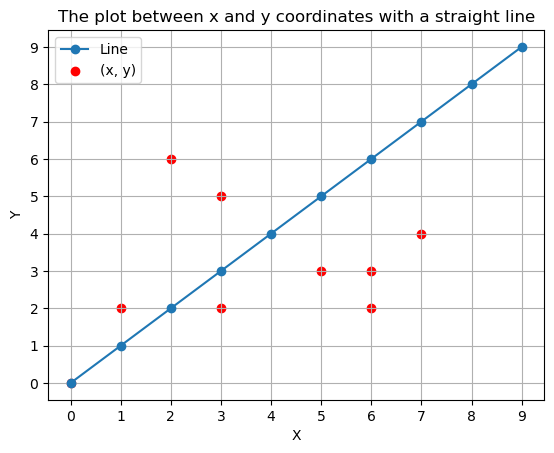

In [464]:
import matplotlib.pyplot as plt

plt.plot(coords, coords, marker='o' ,label="Line")
plt.scatter(csv_file["x"], csv_file["y"], label="(x, y)", color="red")
plt.xlabel("X")
plt.ylabel("Y")
plt.xticks([i for i in range(max(len(coords), len(csv_file['x'])))])
plt.yticks([i for i in range(max(len(coords), len(csv_file['y'])))])

plt.legend()
plt.title("The plot between x and y coordinates with a straight line")

plt.grid()

plt.show()

In [441]:
x1, y1 = coords[0], coords[0]
x2, y2 = coords[-1], coords[-1]


for index, points in csv_file.iterrows():
    x0 = points[0]
    y0 = points[1]
    distance = abs((y2-y1)*x0 + (x2- x1)*y0 + ((x2*y1)-(x1*y2)))/((y2-y1)**2 + (x2- x1)**2)**(1/2)
    print(f"For the points {(x0, y0)}, the distance : {distance}")






For the points (1, 2), the distance : 2.1213203435596424
For the points (3, 5), the distance : 5.65685424949238
For the points (5, 3), the distance : 5.65685424949238
For the points (2, 6), the distance : 5.65685424949238
For the points (7, 4), the distance : 7.7781745930520225
For the points (6, 2), the distance : 5.65685424949238
For the points (3, 2), the distance : 3.5355339059327373
For the points (6, 3), the distance : 6.363961030678928
For the points (0, 0), the distance : 0.0


# Weeks	Assignments
1.	Read a csv file of telemetry data for each colum find all the statistics

1.	plot the PDF for the telemetry data

1.	Finding the probability of getting a head when we toss a coin and not getting a head 

1.	Find the Conditional probability when enery is 0 and dc_current is 0

1.	Finding the probability of occuring ac_events from all events

3.	Take 3x3 Matrix find rank of matrix, dimension of the matrix, inverse of the matrix,transpose, determinant,invertibility,diagonalization

3.	check whether a given matrix  is invertible or not

3.	Matrix Addition subtraction multiplication


In [28]:
#1 Read a csv file of telemetry data for each colum find all the statistics

In [29]:
import pandas as pd

In [30]:
df = pd.read_csv('telemetry.csv')
df.head()

,date,timestamp,site_id,serial_num,duration,ac_voltage,ac_frequency,dc_voltage,dc_current,temperature,error_seconds,energy
0,2023-08-01,2023-08-01T17:42:18Z,4490206,202307218285,33,247.12,59.98,34.95,0.01,36,0,0
1,2023-08-01,2023-08-01T17:47:40Z,4490206,202307218285,322,247.25,59.90,34.56,0.01,35,0,0
2,2023-08-01,2023-08-01T17:48:04Z,4490206,202307218285,24,246.59,59.99,34.60,0.01,35,0,0
3,2023-08-01,2023-08-01T18:03:20Z,4490206,202307218285,916,245.69,60.07,30.10,0.07,34,0,0
4,2023-08-01,2023-08-01T18:18:35Z,4490206,202307218285,915,247.50,60.07,35.07,0.02,33,0,0


In [31]:
for column in df.columns:
#     try:
#         print()
#         print(f"The mean of {column} is {df[column].mean()}")
#         print(f"The median of {column} is {df[column].median()}")
#         print(f"The mode of {column} is {df[column].mode().iloc[0]}")
        
        
#     except Exception as e:
#         message = e

    if df[column].dtype != 'object':
        print('--------------------------------')
        print(f"The mean of {column} is {df[column].mean()}")
        print(f"The median of {column} is {df[column].median()}")
        print(f"The mode of {column} is {df[column].mode().iloc[0]}")
        
        
        

--------------------------------
The mean of site_id is 4490206.0
The median of site_id is 4490206.0
The mode of site_id is 4490206
--------------------------------
The mean of serial_num is 202307227801.0
The median of serial_num is 202307227367.0
The mode of serial_num is 202307227367
--------------------------------
The mean of duration is 893.185437205315
The median of duration is 932.0
The mode of duration is 932
--------------------------------
The mean of ac_voltage is 249.86766609515647
The median of ac_voltage is 249.94
The mode of ac_voltage is 249.62
--------------------------------
The mean of ac_frequency is 60.00143966995286
The median of ac_frequency is 60.0
The mode of ac_frequency is 59.98
--------------------------------
The mean of dc_voltage is 34.2151001928847
The median of dc_voltage is 34.485
The mode of dc_voltage is 34.57
--------------------------------
The mean of dc_current is 4.204617981140163
The median of dc_current is 3.25
The mode of dc_current is 0.02


In [32]:
#2 plot the PDF for the telemetry data

In [58]:

def print_plot(col):
    sns.kdeplot(telemetry_df[col])
#     plt.xlabel(col)
#     plt.ylabel('Probability Density')
#     plt.title(f'Probability Density Function (PDF) of {col}')
#     plt.legend()
#     plt.grid(True)
#     plt.show()
    


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


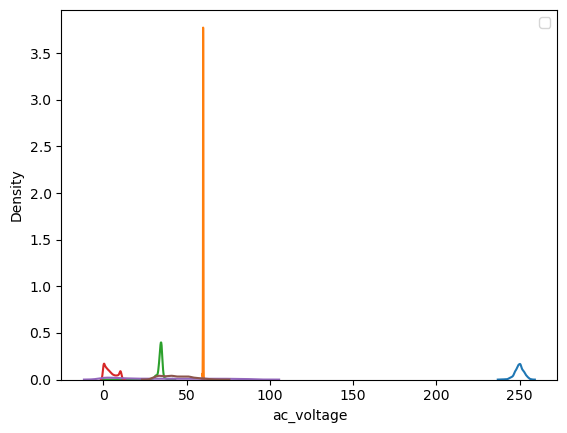

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns

cols = ['ac_voltage', 'ac_frequency', 'dc_voltage', "dc_current", "energy", "temperature"]
for col in cols:
    print_plot(col)





In [35]:
#3 Finding the probability of getting a head when we toss a coin and not getting a head 

In [36]:
def calc_probability_of_heads(total_set):
    total = len(total_set)
    no_of_heads = total_set.count(0)
    print(f"Number of Heads : {no_of_heads}")
    print(f"Number of Tails : {total - no_of_heads}")
    print(f"Total outcomes : {total}")
    prob_of_head = no_of_heads / total;
    return prob_of_head

In [37]:
from random import randint
from time import sleep


number_of_flips = int(input("Enter the number of tosses : "))
 
 
total_set = []

for i in range(number_of_flips):
    result = randint(0 ,1)
    print("Head" if result==0 else "Tails")
    sleep(0.7)
    total_set.append(result)
 
result = round(calc_probability_of_heads(total_set)*100, 2)

print(f"The probability of head is : {result}%")
print(f"The probability of not getting head is : {100- result}%")

Enter the number of tosses : 4
Tails
Head
Head
Head
Number of Heads : 3
Number of Tails : 1
Total outcomes : 4
The probability of head is : 75.0%
The probability of not getting head is : 25.0%


In [38]:
#4 Find the Conditional probability when enery is 0 and dc_current is 0

In [39]:

# energy_0 = len(df[df['energy'] == 0])
# total_energy = df['energy'].count()

# dc_current_0 = len(df[df['dc_current'] == 0])
# total_dc_current = df['dc_current'].count()


# print("Conditional probability of energy being 0:", energy_0/total_energy*100)
# print("Conditional probability of dc_current being 0:", dc_current_0/total_dc_current*100)

total_dc_current_0 = (df['dc_current'] == 0).sum()
total_energy_0 = (df['energy'] == 0).sum()

total_both_0 = ((df['energy'] == 0) & (df['dc_current'] == 0)).sum()
print(f"Joint probability of dc_current and energy {total_both_0}")

conditional_probability_dc_current = total_both_0 / total_dc_current_0
conditional_probability_energy = total_both_0 / total_energy_0

print("Conditional probability of energy being 0 given dc_current is 0:", conditional_probability_energy)
print("Conditional probability of dc current being 0 given energy is 0:", conditional_probability_dc_current)


Joint probability of dc_current and energy 47
Conditional probability of energy being 0 given dc_current is 0: 0.038118410381184104
Conditional probability of dc current being 0 given energy is 0: 0.7580645161290323


In [40]:
#5 Finding the probability of occuring ac_events from all events

In [41]:
df_with_event_key_ac_events = event_df[event_df['event_key'].str.contains("ac_")]
 
ac_events_records = len(df_with_event_key_ac_events)
total_records = len(df)
 
prob_of_ac_events = ac_events_records/total_records
 
print(f"The probability of ac events : {prob_of_ac_events}")

The probability of ac events : 0.016555936562366053


In [42]:
#6 Take 3x3 Matrix find rank of matrix, dimension of the matrix, inverse of the matrix,transpose, determinant,invertibility,
# diagonalization

In [43]:
import numpy as np

matrix = np.array([[3,4,5],[1,2,3],[7,8,9]])
matrix

array([[3, 4, 5],
       [1, 2, 3],
       [7, 8, 9]])

In [44]:
rank = np.linalg.matrix_rank(matrix)
rank

2

In [45]:
dimension = matrix.shape
dimension

(3, 3)

In [46]:
try:
    inverse = np.linalg.inv(matrix)
except np.linalg.LinAlgError:
    inverse = "Matrix is not invertible (singular)"
inverse

array([[-4.11198227e+15,  2.74132151e+15,  1.37066076e+15],
       [ 8.22396454e+15, -5.48264302e+15, -2.74132151e+15],
       [-4.11198227e+15,  2.74132151e+15,  1.37066076e+15]])

In [47]:
transpose = np.transpose(matrix)
transpose

array([[3, 1, 7],
       [4, 2, 8],
       [5, 3, 9]])

In [48]:
determinant = np.linalg.det(matrix)
determinant

1.4591502609359235e-15

In [49]:
invertible = True if determinant != 0 else False
invertible


True

In [50]:
eigenvalues, eigenvectors = np.linalg.eig(matrix)
linearly_independent = np.linalg.matrix_rank(eigenvectors) == len(eigenvectors)
linearly_independent

True

In [51]:
print("Rank of the matrix:", rank)
print("Dimension of the matrix:", dimension)
print("Inverse of the matrix:\n", inverse)
print("Transpose of the matrix:\n", transpose)
print("Determinant of the matrix:", determinant)
print("Is the matrix invertible?", invertible)
print("Can the matrix be diagonalized?", linearly_independent)

Rank of the matrix: 2
Dimension of the matrix: (3, 3)
Inverse of the matrix:
 [[-4.11198227e+15  2.74132151e+15  1.37066076e+15]
 [ 8.22396454e+15 -5.48264302e+15 -2.74132151e+15]
 [-4.11198227e+15  2.74132151e+15  1.37066076e+15]]
Transpose of the matrix:
 [[3 1 7]
 [4 2 8]
 [5 3 9]]
Determinant of the matrix: 1.4591502609359235e-15
Is the matrix invertible? True
Can the matrix be diagonalized? True


In [52]:
#7 check whether a given matrix  is invertible or not

In [53]:

matrix = np.array([[1, 2, 3],
                   [0, 1, 4],
                   [5, 6, 0]])

determinant = np.linalg.det(matrix)

if determinant != 0:
    print("The matrix is invertible.")
else:
    print("The matrix is not invertible (singular).")


The matrix is invertible.


In [54]:
#8 Matrix Addition subtraction multiplication

In [55]:

matrix1 = np.array([[1, 2, 3],
                    [4, 5, 6],
                    [7, 8, 9]])

matrix2 = np.array([[9, 8, 7],
                    [6, 5, 4],
                    [3, 2, 1]])

addition_result = matrix1 + matrix2

subtraction_result = matrix1 - matrix2

multiplication_result = np.dot(matrix1, matrix2)

print("Matrix Addition:")
print(addition_result)

print("\nMatrix Subtraction:")
print(subtraction_result)

print("\nMatrix Multiplication:")
print(multiplication_result)


Matrix Addition:
[[10 10 10]
 [10 10 10]
 [10 10 10]]

Matrix Subtraction:
[[-8 -6 -4]
 [-2  0  2]
 [ 4  6  8]]

Matrix Multiplication:
[[ 30  24  18]
 [ 84  69  54]
 [138 114  90]]


In [305]:
import pandas as pd

telemetry_df = pd.read_csv('telemetry.csv')
event_df = pd.read_csv('events.csv')
# telemetry_df['timestamp'] = pd.to_datetime(telemetry_df['timestamp'])
# event_df['event_start_timestamp'] = pd.to_datetime(event_df['event_start_timestamp'])
# event_df['event_clear_timestamp'] = pd.to_datetime(event_df['event_clear_timestamp'])
i=3
serial_nums = telemetry_df['serial_num'].unique()
telemetry_df = telemetry_df[telemetry_df['serial_num'] == serial_nums[i]]
event_df = event_df[event_df['serial_num'] == serial_nums[i]]



In [306]:
combined_data = []
for index, telemetry_row in telemetry_df.iterrows():
    for index, event_row in event_df.iterrows():
        if (telemetry_row['timestamp'] >= event_row['event_start_timestamp'] and 
            telemetry_row['timestamp'] <= event_row['event_clear_timestamp']):
            combined_row = {**dict(telemetry_row), **dict(event_row)}
            combined_data.append(combined_row)
combined_df = pd.DataFrame(combined_data)

timestamp_values = combined_df['timestamp'].unique()


combined_data = []
for timestamp in timestamp_values:
    values = combined_df[combined_df['timestamp'] == timestamp]
    dictionary = dict()
    for col in values.columns:
        dictionary[col] = values[col].unique()[0] 
    dictionary['event_type_id'] = values['event_type_id'].unique()
    dictionary['event_key'] = values['event_key'].unique()
    dictionary['stateful'] = values['stateful'].unique()
    dictionary['event_start_timestamp'] = values['event_start_timestamp'].unique()
    dictionary['event_clear_timestamp'] = values['event_clear_timestamp'].unique()
    
    combined_data.append(dictionary)
    
combined_df = pd.DataFrame(combined_data)
combined_df



    
    
# combined_df = pd.DataFrame(combined_data)
# combined_df




        

,date,timestamp,site_id,serial_num,duration,ac_voltage,ac_frequency,dc_voltage,dc_current,temperature,error_seconds,energy,event_type_id,event_key,stateful,event_start_timestamp,event_clear_timestamp
0,2023-08-01,2023-08-01T17:43:05Z,4490206,202307226999,12,246.94,59.97,34.82,0.03,34,0,0,"[2, 3, 678, 1027]","[ac_voltage_out_of_range, ac_freq_out_of_range...",[1],[2023-08-01T17:42:54Z],[2023-08-01T17:43:05Z]
1,2023-08-01,2023-08-01T17:47:37Z,4490206,202307226999,272,247.25,59.91,34.28,0.03,34,0,0,[14],[commanded_reset],[0],[2023-08-01T17:47:37Z],[2023-08-01T17:47:37Z]
2,2023-08-01,2023-08-01T18:18:32Z,4490206,202307226999,914,247.56,60.07,34.97,0.01,32,0,0,"[2, 678, 1027]","[ac_voltage_out_of_range, island_detected, pcu...",[1],[2023-08-01T18:18:32Z],[2023-08-01T18:18:46Z]
3,2023-08-01,2023-08-01T18:18:46Z,4490206,202307226999,14,247.19,60.03,30.43,0.06,32,0,0,"[2, 3, 678, 1027]","[ac_voltage_out_of_range, ac_freq_out_of_range...",[1],"[2023-08-01T18:18:32Z, 2023-08-01T18:18:46Z]",[2023-08-01T18:18:46Z]
4,2023-08-03,2023-08-03T12:58:12Z,4490206,202307226999,934,250.66,59.89,40.03,0.01,60,0,75,[678],[island_detected],[1],[2023-08-03T12:58:12Z],[2023-08-03T12:58:42Z]
5,2023-08-03,2023-08-03T12:58:42Z,4490206,202307226999,30,251.16,59.91,41.42,0.01,60,0,0,[678],[island_detected],[1],[2023-08-03T12:58:12Z],[2023-08-03T12:58:42Z]
6,2023-08-09,2023-08-09T09:07:22Z,4490206,202307226999,934,241.22,59.78,33.87,2.39,44,0,26,[678],[island_detected],[1],[2023-08-09T09:07:22Z],[2023-08-09T09:07:51Z]
7,2023-08-09,2023-08-09T09:07:50Z,4490206,202307226999,28,241.94,59.59,31.59,2.53,44,0,1,[678],[island_detected],[1],[2023-08-09T09:07:22Z],[2023-08-09T09:07:51Z]
8,2023-08-09,2023-08-09T09:39:04Z,4490206,202307226999,14,254.03,60.01,34.32,8.32,46,0,1,"[3, 678]","[ac_freq_out_of_range, island_detected]",[1],[2023-08-09T09:38:51Z],[2023-08-09T09:39:04Z]
9,2023-08-09,2023-08-09T16:22:43Z,4490206,202307226999,926,248.16,59.91,41.34,0.01,44,0,32,"[3, 678]","[ac_freq_out_of_range, island_detected]",[1],[2023-08-09T16:22:43Z],[2023-08-09T16:22:58Z]


In [298]:
combined_data

[{'date': '2023-08-01',
  'timestamp': Timestamp('2023-08-01 17:43:05+0000', tz='UTC'),
  'site_id': 4490206,
  'serial_num': 202307226999,
  'duration': 12,
  'ac_voltage': 246.94,
  'ac_frequency': 59.97,
  'dc_voltage': 34.82,
  'dc_current': 0.03,
  'temperature': 34,
  'error_seconds': 0,
  'energy': 0,
  'event_type_id': array([   2,    3,  678, 1027], dtype=int64),
  'event_key': array(['ac_voltage_out_of_range', 'ac_freq_out_of_range',
         'island_detected', 'pcu_chan_loss_of_phase_12'], dtype=object),
  'stateful': 1,
  'event_start_timestamp': Timestamp('2023-08-01 17:42:54+0000', tz='UTC'),
  'event_clear_timestamp': Timestamp('2023-08-01 17:43:05+0000', tz='UTC')},
 {'date': '2023-08-01',
  'timestamp': Timestamp('2023-08-01 17:47:37+0000', tz='UTC'),
  'site_id': 4490206,
  'serial_num': 202307226999,
  'duration': 272,
  'ac_voltage': 247.25,
  'ac_frequency': 59.91,
  'dc_voltage': 34.28,
  'dc_current': 0.03,
  'temperature': 34,
  'error_seconds': 0,
  'energy': 0

In [304]:
telemetry_df['timestamp'].value_counts()

timestamp
2023-08-01T17:42:53Z    1
2023-08-19T10:28:29Z    1
2023-08-19T09:57:24Z    1
2023-08-19T09:41:52Z    1
2023-08-19T09:26:19Z    1
                       ..
2023-08-10T11:48:56Z    1
2023-08-10T11:33:24Z    1
2023-08-10T11:17:52Z    1
2023-08-10T11:02:20Z    1
2023-08-27T18:37:38Z    1
Name: count, Length: 1336, dtype: int64